<h1> Annimation of flaring in the permian region <h1>

Importing necessary libraries

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx

from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm

Importing the required files and columns

In [2]:
path = "../../data/raw/texas/coordinates/production_disp_with_lease_coordinates.geoparquet"

gdf = gpd.read_parquet(path)

print(gdf.columns)
print(gdf.crs)

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'oil_pipeline_bbl', 'oil_truck_bbl', 'oil_tankcar_bbl',
       'oil_tank_cleaning_bbl', 'oil_circulating_bbl', 'oil_lost_stolen_bbl',
       'oil_bsw_repressure_bbl', 'oil_legacy_bbl', 'oil_skimmed_bbl',
       'oil_scrubber_bbl', 'oil_no_disp_code_bbl', 'csgd_field_ops_fuel_mcf',
       'csgd_transmission_mcf', 'csgd_processing_plant_mcf',
       'csgd_vented_flared_mcf', 'csgd_gas_lift_mcf', 'csgd_repressure_mcf',
       'csgd_carbon_black_mcf', 'csgd_underground_storage_mcf',
       'csgd_no_disp_code_mcf', 'oil_sold_total_bbl',
       'total_vented_flared_mcf', 'oil_gas_code_norm', 'district_no_norm',
       'lease_no_norm', 'lease_key', 'n_wells_with_coordinates', 'county_name',
       'lease_longitude', 'lease_latitude', 'geometry'],
      dtype='str')
{"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World

In [3]:
gdf['date'] = pd.to_datetime(gdf['cycle_year_month'], format = '%Y%m')
gdf.date.head()

0   2026-03-01
1   2026-01-01
2   2026-02-01
3   2026-03-01
4   2026-01-01
Name: date, dtype: datetime64[us]

In [4]:
gdf[['lease_key','oil_sold_total_bbl']].sample(15)

,lease_key,oil_sold_total_bbl
12004872,O_03_12866,0
64334,O_13_16774,487
5460396,O_10_37620,1601
9843623,O_11_13219,129
1644264,O_10_20776,90
1831971,O_03_27168,1096
6884246,O_11_69709,0
5171731,O_02_10027,704
2485225,O_08_31747,0
10251098,O_04_11735,143


In [5]:
gdf['lease_key'].sample(1).values[0]
test = gdf.loc[gdf.lease_key == gdf['lease_key'].sample(1).values[0]]

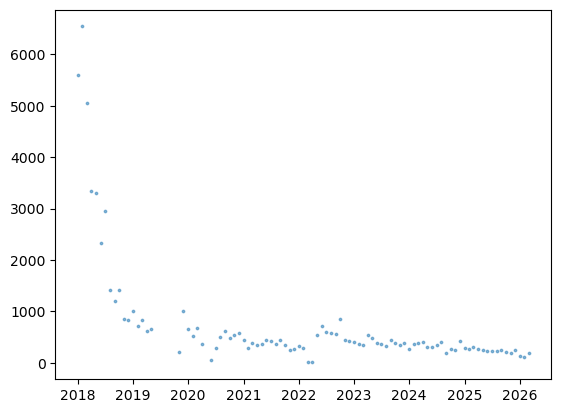

In [50]:
test = gdf.loc[gdf.lease_key == gdf['lease_key'].sample(1).values[0]]
test = test[['date','oil_sold_total_bbl']]

plt.scatter(test.date,test.oil_sold_total_bbl,s = 3, alpha= 0.5)

In [16]:
date_col = "date"                            # monthly date column
flare_col = "total_vented_flared_mcf"        # gas flared volume
lease_col = "lease_key"                      # lease identifier
wells_col = "n_wells_with_coordinates"       # number of wells

Narrow down to the permian region

In [ ]:
gdf["period"] = gdf[date_col].dt.to_period("M").dt.to_timestamp()

# Make sure data is in lon/lat first
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")

gdf_4326 = gdf.to_crs(epsg=4326)

# Approximate Texas Permian bounding box
min_lon = -106.8
max_lon = -100.5
min_lat = 29.0
max_lat = 33.0

permian_gdf = gdf_4326.cx[min_lon:max_lon, min_lat:max_lat].copy()

Narrow down to the time period needed

In [119]:
start_date = "2019-01-01"
end_date = "2025-12-01"

sub = permian_gdf[
    (permian_gdf["period"] >= start_date) &
    (permian_gdf["period"] <= end_date)
].copy()

# Only show leases when they have flared gas
sub = sub[sub[flare_col].fillna(0) > 0].copy()

Reproject for basemap display: Most web basemaps use EPSG:3857.

In [120]:
if sub.crs is None:
    sub = sub.set_crs("EPSG:4326")

sub_3857 = sub.to_crs(epsg=3857)

months = pd.date_range(
    pd.to_datetime(start_date),
    pd.to_datetime(end_date),
    freq="MS"
)

Set marker size based on number of wells

In [89]:
# Color scale represents gas flared
vmax_flare = sub_3857[flare_col].quantile(0.99)

# Size scale represents number of wells
max_wells = sub_3857[wells_col].quantile(0.99)

def marker_size_from_wells(values):
    values = np.asarray(values)
    values = np.nan_to_num(values, nan=0)

    scaled = np.sqrt(values) / np.sqrt(max_wells)
    scaled = np.clip(scaled, 0, 1)

    return 20 + scaled * 450

Create the animation:

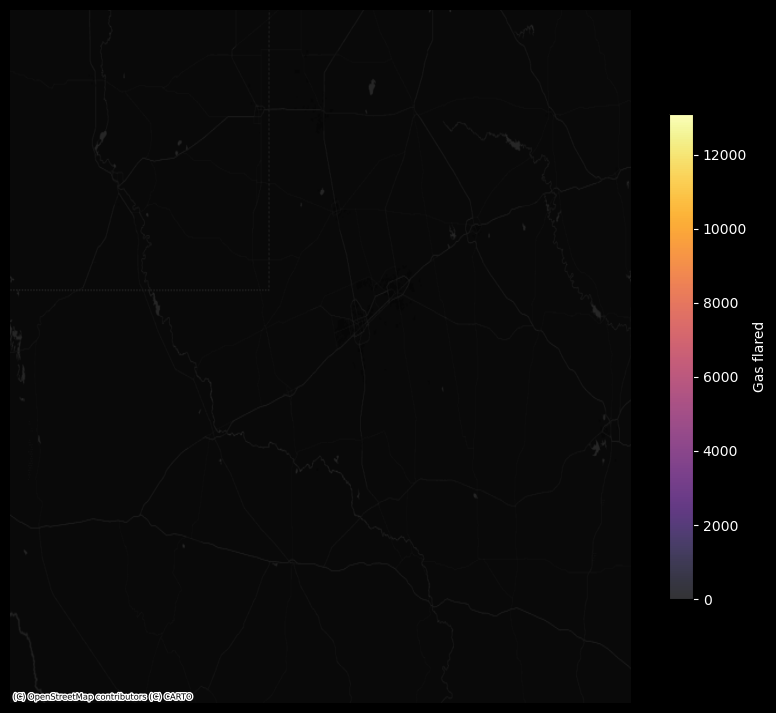

In [90]:
fig, ax = plt.subplots(figsize=(10, 9))

xmin, ymin, xmax, ymax = sub_3857.total_bounds

xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Dark basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.DarkMatterNoLabels,
    attribution_size=6
)

ax.set_axis_off()

norm = Normalize(vmin=0, vmax=vmax_flare)

scatter = ax.scatter(
    [],
    [],
    s=[],
    c=[],
    cmap="inferno",
    norm=norm,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.2
)

title = ax.set_title(
    "",
    fontsize=16,
    color="white",
    pad=12
)

total_text = ax.text(
    0.02,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=11,
    color="white",
    bbox=dict(facecolor="black", alpha=0.65, edgecolor="none")
)

# Colorbar for gas flaring
cbar = fig.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label("Gas flared", color="white")

cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

# Make figure background dark too
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

In [91]:
def update(frame_index):
    month = months[frame_index]

    # Because sub_3857 already excludes zero-flaring rows,
    # this frame only includes leases that flared in this month.
    frame = sub_3857[sub_3857["period"] == month].copy()

    if len(frame) == 0:
        scatter.set_offsets(np.empty((0, 2)))
        scatter.set_sizes([])
        scatter.set_array(np.array([]))

        title.set_text(f"Texas Gas Flaring — {month.strftime('%B %Y')}")
        total_text.set_text("No reported flaring this month")

        return scatter, title, total_text

    x = frame.geometry.x.values
    y = frame.geometry.y.values

    flared_values = frame[flare_col].fillna(0).values
    well_values = frame[wells_col].fillna(0).values

    offsets = np.column_stack([x, y])

    scatter.set_offsets(offsets)

    # Dot size is based on number of wells
    scatter.set_sizes(marker_size_from_wells(well_values))

    # Dot color is based on gas flared
    scatter.set_array(np.clip(flared_values, 0, vmax_flare))

    monthly_total = flared_values.sum()
    active_leases = len(frame)
    total_wells = well_values.sum()

    title.set_text(f"Texas Permian Gas Flaring — {month.strftime('%B %Y')}")

    total_text.set_text(
        f"Monthly flared gas: {monthly_total:,.0f}\n"
        f"Flaring leases: {active_leases:,.0f}\n"
        f"Wells on flaring leases: {total_wells:,.0f}"
    )

    return scatter, title, total_text

In [92]:
anim = FuncAnimation(
    fig,
    update,
    frames=len(months),
    interval=400,
    blit=False
)

In [93]:
writer = FFMpegWriter(fps=4, bitrate=2200)

anim.save(
    "texas_permian_gas_flaring_animation.mp4",
    writer=writer,
    dpi=150
)

<h3> Animated heatmap <h3>

Because flaring volumes are usually very skewed, a log color scale is useful.

In [111]:
vmax = sub_3857[flare_col].quantile(0.99)

# Avoid LogNorm problems with zero values
vmin = max(1, sub_3857[flare_col][sub_3857[flare_col] > 0].quantile(0.05))

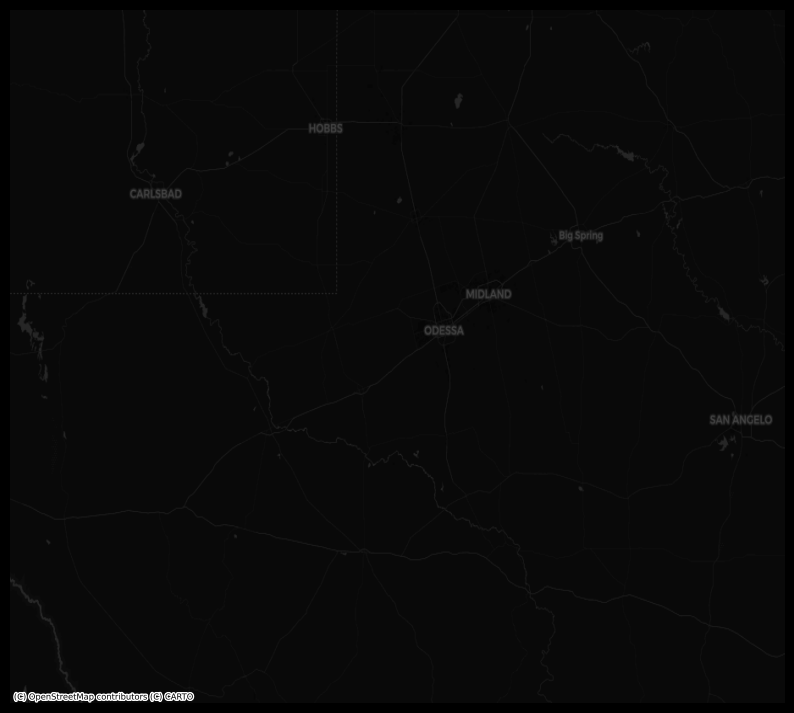

In [112]:
fig, ax = plt.subplots(figsize=(10, 9))

xmin, ymin, xmax, ymax = sub_3857.total_bounds

xpad = (xmax - xmin) * 0.08
ypad = (ymax - ymin) * 0.08

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Dark basemap
cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.DarkMatter,
    attribution_size=6
)

ax.set_axis_off()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

title = ax.set_title(
    "",
    fontsize=16,
    color="white",
    pad=12
)

info_text = ax.text(
    0.02,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=11,
    color="white",
    bbox=dict(facecolor="black", alpha=0.65, edgecolor="none")
)

In [113]:
hexbin_obj = None
cbar = None

def update(frame_index):
    global hexbin_obj, cbar

    month = months[frame_index]
    frame = sub_3857[sub_3857["period"] == month].copy()

    # Remove previous heatmap layer, but keep basemap/title/text
    for coll in ax.collections:
        coll.remove()

    title.set_text(f"Permian Region Gas Flaring Heatmap — {month.strftime('%B %Y')}")

    if len(frame) == 0:
        info_text.set_text("No reported flaring this month")
        return title, info_text

    x = frame.geometry.x.values
    y = frame.geometry.y.values
    weights = frame[flare_col].fillna(0).values

    hexbin_obj = ax.hexbin(
        x,
        y,
        C=weights,
        reduce_C_function=np.sum,
        gridsize=65,
        cmap="inferno",
        norm=LogNorm(vmin=vmin, vmax=vmax),
        mincnt=1,
        alpha=0.80,
        linewidths=0
    )

    monthly_total = weights.sum()
    active_leases = len(frame)

    info_text.set_text(
        f"Monthly flared gas: {monthly_total:,.0f}\n"
        f"Flaring lease-month records: {active_leases:,.0f}"
    )

    return hexbin_obj, title, info_text

In [114]:
anim = FuncAnimation(
    fig,
    update,
    frames=len(months),
    interval=400,
    blit=False
)

In [115]:
writer = FFMpegWriter(fps=4, bitrate=2200)

anim.save(
    "permian_gas_flaring_heatmap.mp4",
    writer=writer,
    dpi=150
)

In [ ]:
well_co = pd.read_parquet('../../data/raw/texas/coordinates/production_joined_to_well_points.parquet')

In [3]:
well_co.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'cycle_year_month',
       'field_no', 'lease_oil_prod_vol', 'lease_csgd_prod_vol',
       'lease_csgd_tot_disp', 'prod_date', 'oil_gas_code_norm',
       'district_no_norm', 'lease_no_norm', 'lease_key', 'api8', 'well_no',
       'county_name', 'longitude', 'latitude'],
      dtype='str')

In [6]:
well_co[['cycle_year_month','well_no','lease_key','latitude','longitude']].head(25)

,cycle_year_month,well_no,lease_key,latitude,longitude
0,202601,44,O_02_05905,28.257481,-97.220040
1,202601,55,O_02_05905,28.253792,-97.228268
2,202602,44,O_02_05905,28.257481,-97.220040
3,202602,55,O_02_05905,28.253792,-97.228268
4,202603,44,O_02_05905,28.257481,-97.220040
5,202603,55,O_02_05905,28.253792,-97.228268
6,202604,44,O_02_05905,28.257481,-97.220040
7,202604,55,O_02_05905,28.253792,-97.228268
8,202605,44,O_02_05905,28.257481,-97.220040
9,202605,55,O_02_05905,28.253792,-97.228268


In [7]:
well_co = pd.read_parquet('../../data/raw/texas/coordinates/lease_well_coordinates.parquet')

In [8]:
well_co.columns

Index(['oil_gas_code', 'district_no', 'lease_no', 'well_no', 'api_county_code',
       'api_unique_no', 'county_name', 'wellbore_location_code', 'api_no',
       'oil_gas_code_norm', 'district_no_norm', 'lease_no_norm', 'lease_key',
       'api8_from_components', 'api8_from_api_no', 'api8', 'longitude',
       'latitude', 'SOURCE_ZIP', 'SOURCE_SHP', 'well_layer_type', 'API',
       'API10', 'APINUM', 'LAT27', 'LONG27', 'LAT83', 'LONG83', 'RELIAB',
       'SYMNUM', 'WELLID'],
      dtype='str')

In [9]:
well_co[['lease_no', 'well_no','api8', 'longitude','latitude']].head(20)

,lease_no,well_no,api8,longitude,latitude
0,00277,17,04931721,-99.098679,32.045194
1,00277,18,04932950,-99.101261,32.045274
2,00287,1,04905559,-99.085963,32.056174
3,00291,1,04905919,-99.059271,32.039860
4,00291,2,04980560,-99.059242,32.041674
5,00291,3,04930486,-99.059205,32.044039
6,00291,4,04904704,-99.063501,32.039778
7,00291,7,04935384,-99.061307,32.042833
8,00292,1,04905369,-99.063029,32.038351
9,00292,2,04980563,-99.058914,32.038067
